In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
stock_data = yf.download("NFLX", start="2025-01-01", end= "2025-12-31")

/tmp/ipython-input-1511981826.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download("NFLX", start="2025-01-01", end= "2025-12-31")
[*********************100%***********************]  1 of 1 completed


In [ ]:
stock_data.index = pd.to_datetime(stock_data.index)
# Group by month and get the last closing price of each month
monthly_data = stock_data['Close'].resample('M').last()

/tmp/ipython-input-1460431164.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = stock_data['Close'].resample('M').last()


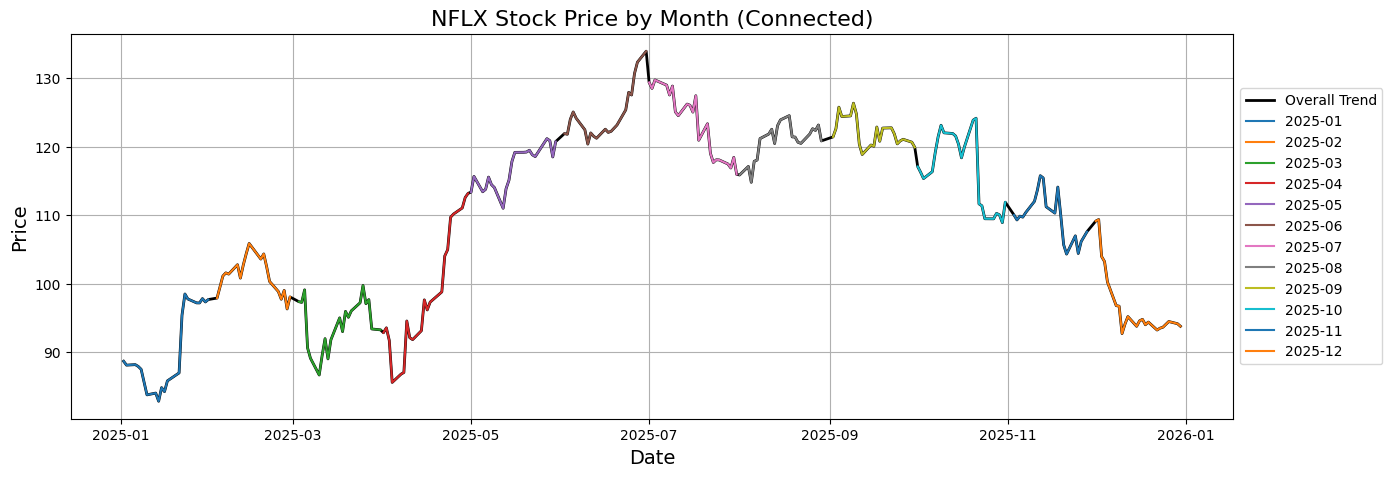

In [ ]:
plt.figure(figsize=(15,5))

# Plot the continuous line first
plt.plot(stock_data.index, stock_data['Close'], color='black', linewidth=2, label='Overall Trend')

# Overlay each month in different colors
for month, data in stock_data.groupby(stock_data.index.to_period('M')):
    plt.plot(data.index, data['Close'], label=str(month))

plt.title('NFLX Stock Price by Month (Connected)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.show()

**Conversion of data from non-stationary to stationary term**

**AR Model**

In [ ]:
stock_data_stationary= stock_data['Close'].diff().dropna()
stock_data_stationary.head()

Ticker,NFLX
Date,
2025-01-03,-0.567993
2025-01-06,0.073997
2025-01-07,-0.260002
2025-01-08,-0.418999
2025-01-10,-3.731003


**Train and Test Split data**

In [ ]:
len(stock_data_stationary)

248

In [ ]:
train_data = stock_data_stationary[:int(0.8*len(stock_data_stationary))]
test_data = stock_data_stationary[int(0.8*len(stock_data_stationary)):]

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error


# fitting AR Model to Dataset
model = AutoReg(train_data, lags=30)
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# prediction on Test data
predictions = model_fit.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1, dynamic = False)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


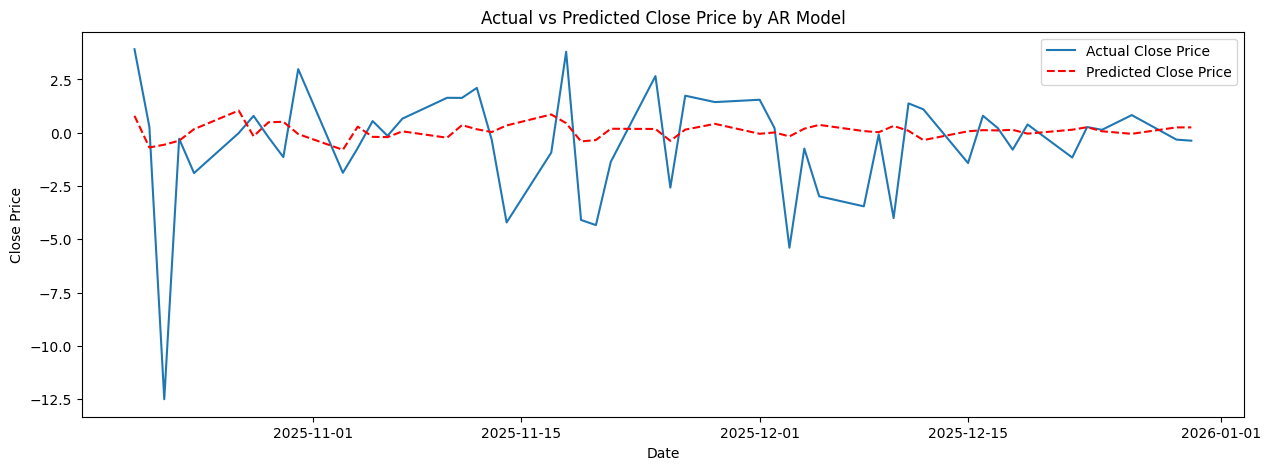

Root Mean Square Error : 2.64


In [ ]:
plt.figure(figsize=(15,5))
plt.plot(test_data.index, test_data, label = 'Actual Close Price')
plt.plot(test_data.index, predictions, color = 'red',linestyle = '--', label = 'Predicted Close Price')
plt.title('Actual vs Predicted Close Price by AR Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

#model evaluation
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print(f'Root Mean Square Error : {rmse}')

**MA Model**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

#Model Fitting
model = ARIMA(train_data, order=(0, 0, 30))    #since there is no specific function for MA therefore taking p=0, d=0, q=30
model_fit = model.fit()

#prediction on test data
predictions = model_fit.predict(start =  len(train_data), end=len(train_data) + len(test_data) - 1, dynamic = False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/ts

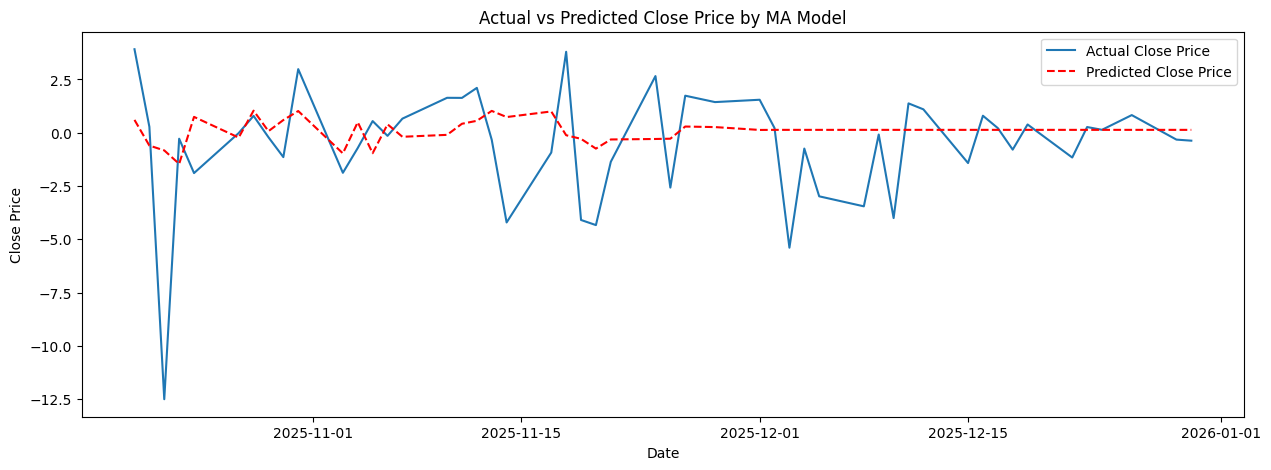

Root Mean Square Error : 2.64


In [ ]:
#plot data
plt.figure(figsize=(15,5))
plt.plot(test_data.index, test_data, label = 'Actual Close Price')
plt.plot(test_data.index, predictions, color = 'red',linestyle = '--', label = 'Predicted Close Price')
plt.title('Actual vs Predicted Close Price by MA Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

#model evaluation
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print(f'Root Mean Square Error : {rmse}')

**ARMA Model**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

#Model Fitting
model = ARIMA(train_data, order=(30, 0, 30))
model_fit = model.fit()

#prediction on test data
predictions = model_fit.predict(start =  len(train_data), end=len(train_data) + len(test_data) - 1, dynamic = False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmode

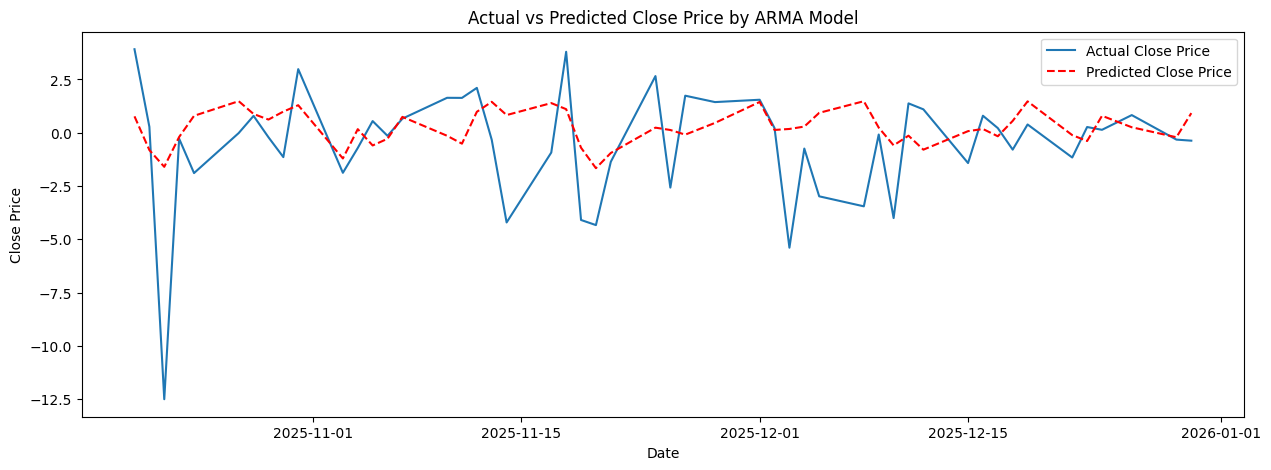

Root Mean Square Error : 2.59


In [ ]:
#plot data
plt.figure(figsize=(15,5))
plt.plot(test_data.index, test_data, label = 'Actual Close Price')
plt.plot(test_data.index, predictions, color = 'red',linestyle = '--', label = 'Predicted Close Price')
plt.title('Actual vs Predicted Close Price by ARMA Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

#model evaluation
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print(f'Root Mean Square Error : {rmse}')

**ARIMA Model**

In [ ]:
#Model Fitting
model = ARIMA(train_data, order=(30, 1, 30))    #since there is no specific function for MA therefore taking p=0, d=0, q=30
model_fit = model.fit()

#prediction on test data
predictions = model_fit.predict(start =  len(train_data), end=len(train_data) + len(test_data) - 1, dynamic = False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmode

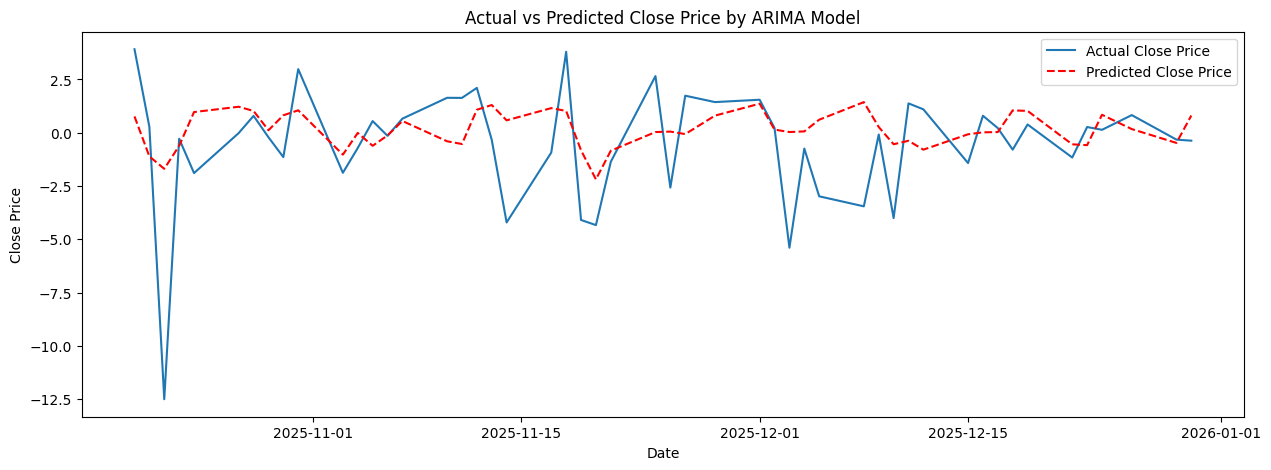

Root Mean Square Error : 2.55


In [ ]:
#plot data
plt.figure(figsize=(15,5))
plt.plot(test_data.index, test_data, label = 'Actual Close Price')
plt.plot(test_data.index, predictions, color = 'red',linestyle = '--', label = 'Predicted Close Price')
plt.title('Actual vs Predicted Close Price by ARIMA Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

#model evaluation
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print(f'Root Mean Square Error : {rmse}')

**SRIMA Model**

In [ ]:
p, d, q = 30,1,30
P, D, Q, s = 30,1,30, 45     #here s is taken checking additive seasonality which repeats after 45 days


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

#Model Fitting
model = SARIMAX(train_data, order = (p, d, q), seasonal_order= (P, D, Q, s))
model_fit = model.fit()

In [ ]:

#prediction on test data
predictions = model_fit.predict(start =  len(train_data), end=len(train_data) + len(test_data) - 1, dynamic = False)

In [ ]:
#plot data
plt.figure(figsize=(15,5))
plt.plot(test_data.index, test_data, label = 'Actual Close Price')
plt.plot(test_data.index, predictions, color = 'red',linestyle = '--', label = 'Predicted Close Price')
plt.title('Actual vs Predicted Close Price by SARIMA Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

#model evaluation
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print(f'Root Mean Square Error : {rmse}')

**Checking Multivariate analysis**

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
disney_data = yf.download("DIS", start="2025-01-01", end= "2025-12-31")
netflix_data = yf.download("NFLX", start="2025-01-01", end= "2025-12-31")


stock_data_multivariare =